### MLP Model made using PyTorch
Relevant Statistics: Made via MLP with 5 layers 1024->output

| Category        | Accuracy  | Precision | Recall   | F1      |
|-----------------|-----------|-----------|----------|---------|
| any             | 0.837519  | 0.803354  | 0.798485 | 0.800912|
| epidural        | 0.621705  | 0.027375  | 0.739130 | 0.052795|
| intraparenchymal| 0.733643  | 0.478357  | 0.815000 | 0.602866|
| intraventricular| 0.684651  | 0.333089  | 0.811052 | 0.472237|
| subarachnoid    | 0.692713  | 0.360354  | 0.799020 | 0.496699|
| subdural        | 0.683411  | 0.341322  | 0.804795 | 0.479347|

AUC overall: 0.83

# Hemorrhage Detection MLP Model K-Fold Evaluation

This notebook loads the optimized MLP model from the saved weights and evaluates it using K-fold cross-validation with k={3,5,10}. The process follows these steps:

1. Setup and Data Preparation
2. Load Pre-trained Model and Hyperparameters
3. K-Fold Cross Validation
4. Performance Analysis and Visualization
5. Statistical Comparison of Different K-Folds

## 1. Setup and Data Preparation

In [2]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [3]:
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0

    def __call__(self, val_loss):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

class HemorrhageMLP(nn.Module):
    """Dynamic MLP model for hemorrhage detection."""
    def __init__(self, input_size, output_size, layer_sizes, dropout_rates):
        super(HemorrhageMLP, self).__init__()
        
        layers = []
        prev_size = input_size

        for i, size in enumerate(layer_sizes):
            layers.append(nn.Linear(prev_size, size))
            layers.append(nn.BatchNorm1d(size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rates[i]))
            prev_size = size

        layers.append(nn.Linear(prev_size, output_size))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
# --- Load Full Dataset ---
df_hemo = pd.read_csv('../Rsna_ICH_Hemm.csv')
df_control = pd.read_csv('../Rsna_ICH_Control.csv')
df = pd.concat([df_hemo, df_control], ignore_index=True)
df['embedding'] = df['embedding'].apply(eval)
target_columns = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

# Load the full embeddings and target values
X = np.array(df['embedding'].tolist(), dtype=np.float32)
y = df[target_columns].values.astype(np.float32)

print(f"Full dataset shape: X={X.shape}, y={y.shape}")

# --- Load Hyperparameters ---
params_path = 'model_saves/model_hyperparameters.json'
with open(params_path, 'r') as f:
    hyperparams = json.load(f)

best_lr = hyperparams['learning_rate']
best_layer_sizes = hyperparams['layer_sizes']
best_dropout_rates = hyperparams['dropout_rates']
input_size = hyperparams['input_size']
output_size = hyperparams['output_size']

print("\nLoaded hyperparameters:")
print(json.dumps(hyperparams, indent=2))

Full dataset shape: X=(16125, 1408), y=(16125, 6)

Loaded hyperparameters:
{
  "n_layers": 7,
  "layer_sizes": [
    807,
    467,
    258,
    180,
    126,
    85,
    43
  ],
  "dropout_rates": [
    0.19165948584259396,
    0.2520683029657358,
    0.3976052695516048,
    0.44077739067431176,
    0.4108096582517331,
    0.41117403178491185,
    0.17531093031749775
  ],
  "learning_rate": 0.00018774581889,
  "input_size": 1408,
  "output_size": 6
}


In [7]:
# Define the different train sizes to test
train_sizes = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60]
all_metrics_list = []

num_epochs = 50  # Max epochs per split (will stop early)
patience = 5     # Early stopping patience

print(f"\n{'='*30}")
print("STARTING TRAIN/TEST SPLIT EXPERIMENT")
print(f"{'='*30}")

for train_size in train_sizes:
    print(f"\n--- Testing Train Size: {train_size*100:.0f}% ---")
    start_time = time.time()
    
    # 1. Split data (using train_size)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=train_size, random_state=42
    )
    
    # 2. Scale features (Fit on train, transform train/test)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 3. Calculate class weights FOR THIS TRAIN SPLIT
    pos_weights = []
    for i in range(len(target_columns)):
        num_pos = np.sum(y_train[:, i])
        num_neg = y_train.shape[0] - num_pos
        weight = num_neg / (num_pos + 1e-6)
        pos_weights.append(weight)
    pos_weights = torch.tensor(pos_weights, dtype=torch.float32).to(device)
    
    # 4. Create Tensors and DataLoaders
    train_dataset = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), 
                                  torch.tensor(y_train, dtype=torch.float32))
    test_dataset = TensorDataset(torch.tensor(X_test_scaled, dtype=torch.float32), 
                                 torch.tensor(y_test, dtype=torch.float32))
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)
    
    # 5. Initialize a new model for this split
    model = HemorrhageMLP(
        input_size=input_size,
        output_size=output_size,
        layer_sizes=best_layer_sizes,
        dropout_rates=best_dropout_rates
    ).to(device)
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
    optimizer = optim.Adam(model.parameters(), lr=best_lr)
    early_stopper = EarlyStopping(patience=patience)
    
    # 6. Training loop
    for epoch in range(num_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            output = model(xb)
            loss = criterion(output, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                output = model(xb)
                loss = criterion(output, yb)
                val_loss += loss.item() * xb.size(0)
        val_loss /= len(test_loader.dataset)
        
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{num_epochs}, Val Loss: {val_loss:.4f}")
            
        # Early stopping check
        early_stopper(val_loss)
        if early_stopper.early_stop:
            print(f"  Early stopping at epoch {epoch+1}")
            break
            
    # 7. Final Evaluation
    model.eval()
    y_true_split = []
    y_pred_split = []
    y_score_split = []
    
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            output = model(xb)
            probs = torch.sigmoid(output)
            preds = (probs > 0.5)
            
            y_true_split.append(yb.cpu().numpy())
            y_pred_split.append(preds.cpu().numpy())
            y_score_split.append(probs.cpu().numpy())
            
    y_true_split = np.vstack(y_true_split)
    y_pred_split = np.vstack(y_pred_split)
    y_score_split = np.vstack(y_score_split)
    
    # 8. Store metrics for this split
    for i, col in enumerate(target_columns):
        all_metrics_list.append({
            'train_size_pct': train_size * 100,
            'Category': col,
            'Accuracy': accuracy_score(y_true_split[:, i], y_pred_split[:, i]),
            'Precision': precision_score(y_true_split[:, i], y_pred_split[:, i], zero_division=0),
            'Recall': recall_score(y_true_split[:, i], y_pred_split[:, i], zero_division=0),
            'F1': f1_score(y_true_split[:, i], y_pred_split[:, i], zero_division=0),
            'ROC_AUC': roc_auc_score(y_true_split[:, i], y_score_split[:, i])
        })
    
    split_time = time.time() - start_time
    print(f"Train size {train_size*100:.0f}% completed in {split_time:.2f}s")

print("\nExperiment complete.")


STARTING TRAIN/TEST SPLIT EXPERIMENT

--- Testing Train Size: 5% ---
  Epoch 10/50, Val Loss: 0.9744
  Epoch 20/50, Val Loss: 0.9045
  Epoch 30/50, Val Loss: 0.9105
  Early stopping at epoch 34
Train size 5% completed in 26.64s

--- Testing Train Size: 10% ---
  Epoch 10/50, Val Loss: 0.9067
  Epoch 20/50, Val Loss: 0.8816
  Early stopping at epoch 20
Train size 10% completed in 16.25s

--- Testing Train Size: 20% ---
  Epoch 10/50, Val Loss: 0.9210
  Epoch 20/50, Val Loss: 0.9093
  Early stopping at epoch 21
Train size 20% completed in 19.73s

--- Testing Train Size: 30% ---
  Epoch 10/50, Val Loss: 0.8945
  Early stopping at epoch 15
Train size 30% completed in 16.34s

--- Testing Train Size: 40% ---
  Epoch 10/50, Val Loss: 0.9143
  Early stopping at epoch 11
Train size 40% completed in 13.54s

--- Testing Train Size: 50% ---
  Epoch 10/50, Val Loss: 0.8940
  Early stopping at epoch 13
Train size 50% completed in 17.42s

--- Testing Train Size: 60% ---
  Epoch 10/50, Val Loss: 0.88


TRAIN/TEST SPLIT RESULTS
Mean Metrics Across All Categories:
                Accuracy  Precision  Recall      F1  ROC_AUC
train_size_pct                                              
5.0               0.6945     0.3575  0.7186  0.4527   0.7588
10.0              0.7083     0.3631  0.7233  0.4595   0.7751
20.0              0.7279     0.4077  0.7233  0.4799   0.7875
30.0              0.7001     0.3858  0.8015  0.4847   0.7983
40.0              0.7034     0.3814  0.7915  0.4826   0.7960
50.0              0.7209     0.3923  0.7802  0.4912   0.8006
60.0              0.7179     0.3919  0.7829  0.4899   0.8011

PLOTTING METRICS VS. TRAINING SIZE


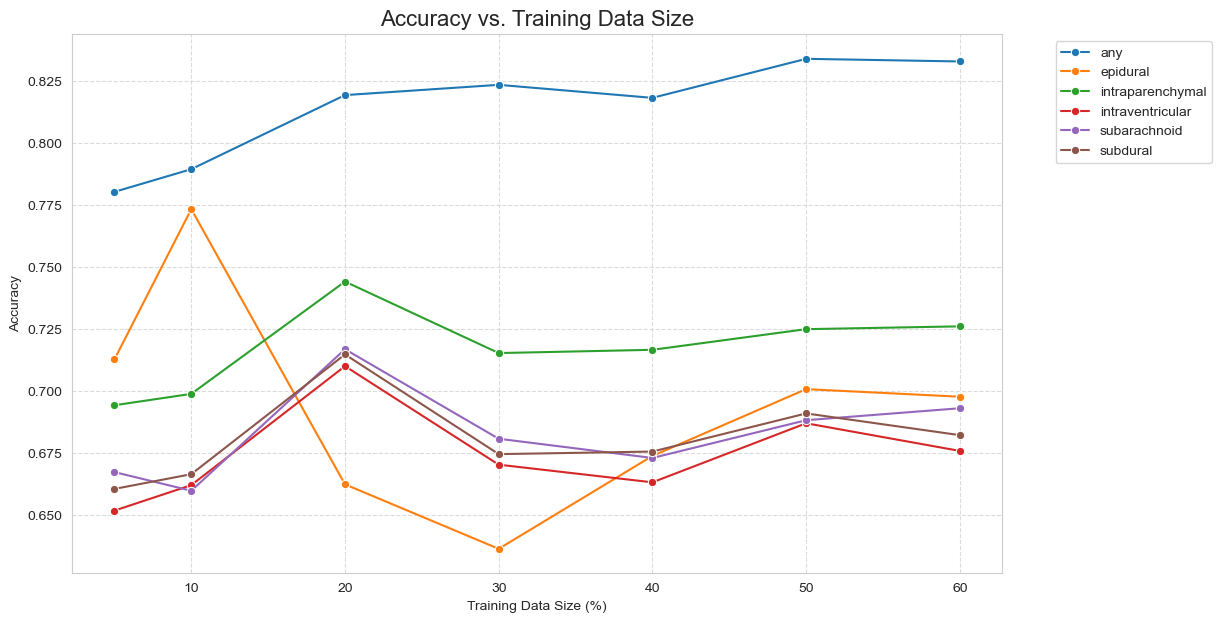

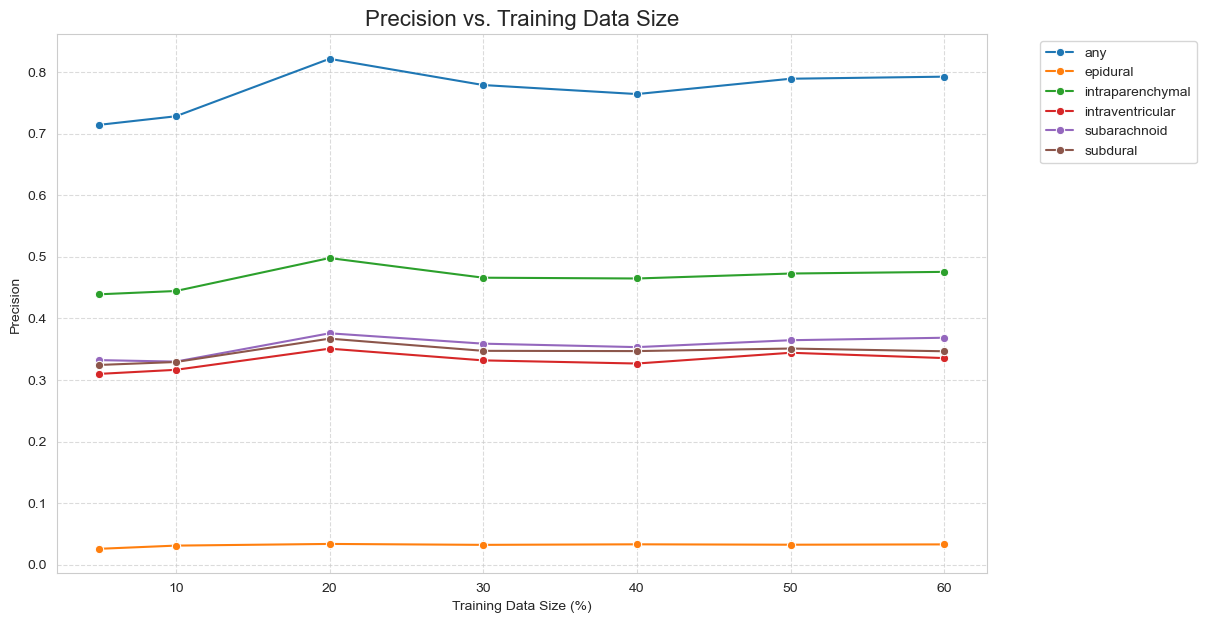

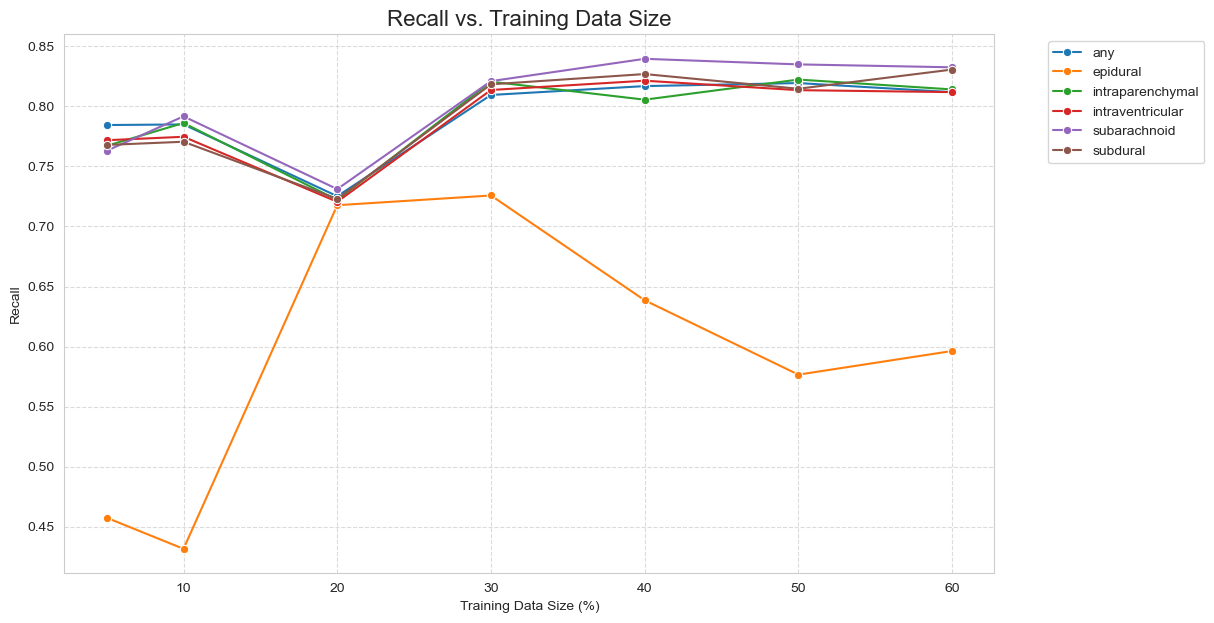

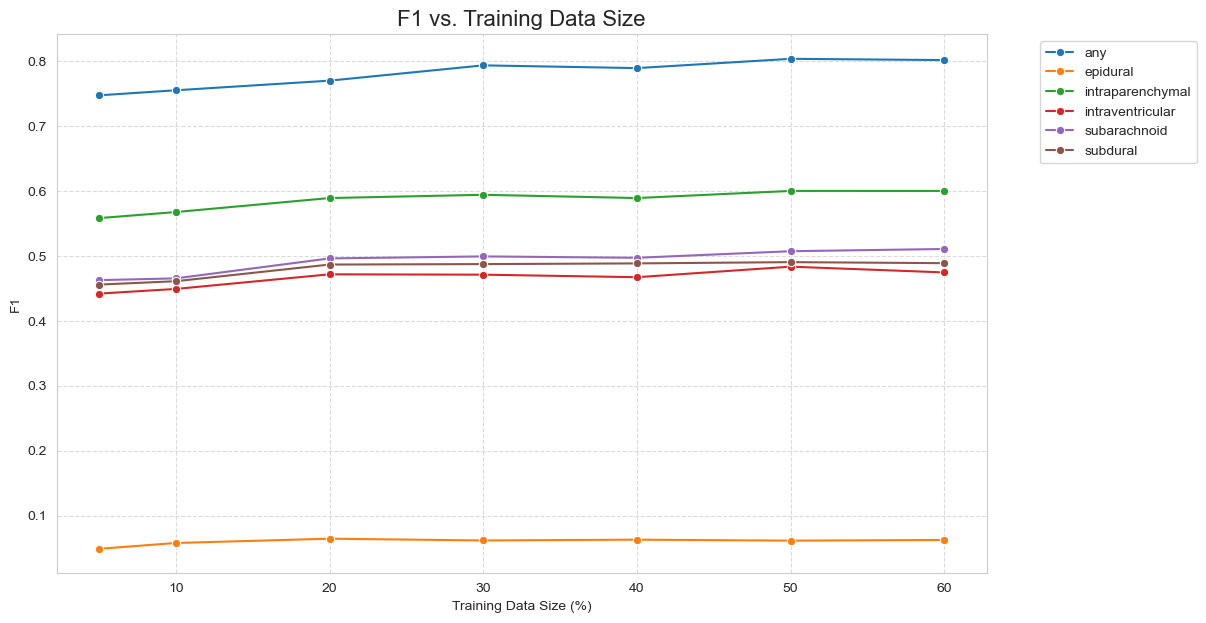

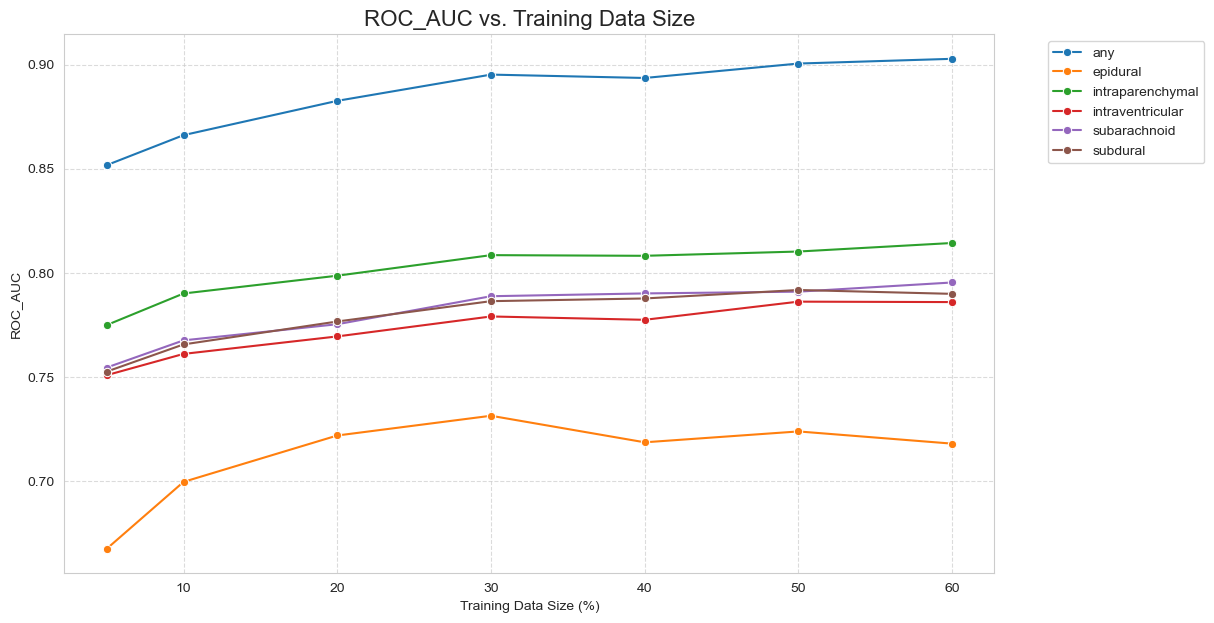

In [8]:
# Convert results list to DataFrame
results_df = pd.DataFrame(all_metrics_list)

print("\n" + "="*50)
print("TRAIN/TEST SPLIT RESULTS")
print("="*50)

# Display a summary table (mean across all categories for each train size)
summary_table = results_df.groupby('train_size_pct')[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']].mean()
print("Mean Metrics Across All Categories:")
print(summary_table.round(4))


print("\n" + "="*50)
print("PLOTTING METRICS VS. TRAINING SIZE")
print("="*50)

# Plot each metric vs. training size, with one line per category
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
sns.set_style("whitegrid")
palette = sns.color_palette("tab10", len(target_columns))

for metric in metrics_to_plot:
    plt.figure(figsize=(12, 7))
    sns.lineplot(
        data=results_df, 
        x='train_size_pct', 
        y=metric, 
        hue='Category', 
        marker='o', 
        palette=palette
    )
    plt.title(f'{metric} vs. Training Data Size', fontsize=16)
    plt.xlabel('Training Data Size (%)')
    plt.ylabel(metric)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()